In [1]:

import PySAM.Pvsamv1 as pvsamv1
import PySAM.Pvwattsv8 as pv #Switch between detailed pvsamv1 and pvwatts depending on use case
import PySAM.Windpower as wind
import PySAM.Battery as batt
import PySAM.Pvsamv1Tools as pvtools
import PySAM.BatteryTools as batttools
import PySAM.CustomGeneration as custom

import PySAM.Singleowner as singleowner
import json

# import the hybrid system class
from PySAM.Hybrids.HybridSystem import HybridSystem
import PySAM
print(PySAM.__version__)



7.1.1.post1


## Build and initialize the hybrid model

This cell creates and prepares a PySAM hybrid system model for a PV + wind + battery configuration.

It performs the following setup steps:

- Creates hybrid model instances (`m` and `m2`) with a `hostdeveloper` financial model.
- Loads default settings for a PV/wind/battery host-developer configuration.
- Shows how to start a new model instance `m` with `m.new()` and sizes PV electrical parameters for a target capacity and DC/AC ratio.
- Loads battery inputs from `Hybrid_PV.json` and assigns them to `batt_model`.
- Assigns JSON-derived inputs to `m` and prints any unassigned variables.
- Sets required solar and wind resource file paths and applies them to the model.

This establishes the baseline hybrid system inputs before additional variable assignments and simulation runs.

In [ ]:
# Create the hybrid system model
m = HybridSystem([pv, wind, batt], 'hostdeveloper')
m2 = HybridSystem([pvsamv1, wind, batt], 'hostdeveloper')
custom_model = HybridSystem([pv, wind, custom], 'hostdeveloper')
batt_model = batt.default("PVWattsWindBatteryHybridHostDeveloper")
# load input values from defaults for the
# PVWatts Wind Battery / Single Owner configuration
# default configuration is for a 100 MW PV system with 80 2.5 MW turbines
m2.default('PhotovoltaicWindBatteryHybridHostDeveloper')
help(m.default)
#m.default('PVWattsWindBatteryHybridHostDeveloper')
m.new()

#Custom generation model for bringing in other production time series power (such as from pvlib)
custom_model.default('CustomGenerationPVWattsWindFuelCellBatteryHybridHostDeveloper')


        
target_capacity = 100000 # kW
target_dc_ac_ratio = 1.2        
pvtools.size_electrical_parameters(m2.pv, target_system_capacity = 100000, target_dc_ac_ratio=1.2)

inputs_file = 'Hybrid_PV.json'
with open(inputs_file, 'r') as f:
        inputs = json.load(f)['input']

batt_inputs = inputs['battery']

for k, v in batt_inputs.items():
    if k != 'number table entries':
        batt_model.value(k, v)
unassigned = m.assign(inputs) # returns a list of unassigned variables if any
print(unassigned)

# assign values to solar and wind resource files (these are not loaded with defaults)
solar_resource_path = 'phoenix_az_33.450495_-111.983688_psmv3_60_tmy.csv'
wind_resource_path =  'AZ Eastern-Rolling Hills.srw'

m.pvwatts.SolarResource.solar_resource_file = solar_resource_path
m.wind.Resource.wind_resource_filename = wind_resource_path

print(m.pvwatts.SolarResource.solar_resource_file)

#Alternative methods for assigning values to the model
# Method 3: Use `assign()` for a 6 MW PV system with three 2.5 MW turbines
# inputs_dict = {
#         "pvwatts": {"SystemDesign": {"system_capacity": 6000} },
#         "wind": {"Farm": {"wind_farm_xCoordinates": [0, 800, 1600]} },
#         "wind": {"Farm": {"wind_farm_yCoordinates": [0, 0, 0]} },
#         "wind": {"Farm": {"system_capacity": 7500} }
# }
# m.assign(inputs_dict)

Help on method default in module PySAM.Hybrids.HybridSystem:

default(config_name: str) method of PySAM.Hybrids.HybridSystem.HybridSystem instance
    Create model with input variables set to default values. Available default configurations are:

        "CustomGenerationPVWattsWindFuelCellBatteryHybridHostDeveloper"
        "CustomGenerationPVWattsWindFuelCellBatteryHybridSingleOwner"
        "PVWattsWindBatteryHybridHostDeveloper"
        "PVWattsWindBatteryHybridSingleOwner"
        "PVWattsWindFuelCellBatteryHybridHostDeveloper"
        "PVWattsWindFuelCellBatteryHybridSingleOwner"
        "PhotovoltaicWindBatteryHybridHostDeveloper"
        "PhotovoltaicWindBatteryHybridSingleOwner"

{'windpower': ['en_timeindex', 'constant', 'en_periods', 'periods', 'timeindex', 'number table entries'], 'pvwattsv8': ['en_periods', 'timeindex', 'en_timeindex', 'constant', 'periods', 'number table entries'], 'battery': ['periods', 'en_periods', 'en_timeindex', 'constant', 'timeindex', 'number table

In [19]:
#Assign more variables

m.battery.BatteryDispatch.batt_dispatch_choice = 5 #Self-consumption dispatch heuristic
#Aligns with 0 index of radio button in SAM UI

m.host_developer.Revenue.ppa_price_input = [0.153] #$/kWh, array of size 1 or analysis_period

## Parametric battery and PV sizing sweep

This cell runs a two-dimensional parametric analysis across battery power and PV system capacity to evaluate hybrid system performance.

- `battery_power` is varied from 0 to 10000 kW in 1000 kW steps.
- `pv_capacity` is varied from 3000 to 10000 kW in 1000 kW steps.
- Battery duration is fixed at 4 hours, so battery energy target is `power * duration`.

For each PV/battery pair, the script:

- Resizes the battery model (with a temporary fallback for any issues).
- Sets PV capacity on the model.
- Executes the hybrid simulation.
- Stores key outputs in `results` (LCOE, PV capacity, battery power, percent load met in year 1, year-1 electric bill, and NPV).

The resulting `results` dictionary is used in the next cells to build pivot tables and heatmaps.

In [ ]:
# Parametric analysis of battery sizing to meet load requirements
import numpy as np
battery_power = np.arange(start=0, stop=10001, step=1000) # in kW
battery_duration = 4 # in hours

pv_capacity = np.arange(start= 3000, stop= 10001, step= 1000) # in kW
results = {}
print(type(m.battery))
for cap in pv_capacity:
    for power in battery_power:
        try:
            batttools.battery_model_sizing(model=m.battery, desired_power=power, desired_capacity= power * battery_duration, desired_voltage=500)
        except: #Until batthybrid bug is fixed
            batttools.battery_model_sizing(model=batt_model, desired_power=power, desired_capacity= power * battery_duration, desired_voltage=500)

            batt_inputs = batt_model.export()
            for k in batt_inputs['BatterySystem']:
                if k != 'number table entries':
                    print(k)
                    m.battery.value(k, batt_model.value(k))
        m.pvwatts.SystemDesign.system_capacity = cap
        m.execute()
        results[f'PV {cap} kW /  Battery {power} kW'] = {
            'LCOE': m.host_developer.Outputs.lcoe_real,
            'PV capacity': m.pvwatts.SystemDesign.system_capacity,
            'Battery power': m.battery.BatterySystem.batt_computed_bank_capacity,
            'Percent load met by system Y1': m.battery.Outputs.percent_ts_load_met_by_system_yr1,
            'Electric bill with system Y1': m.utilityrate5.Outputs.utility_bill_w_sys_year1,
            'NPV': m.host_developer.Outputs.project_return_aftertax_npv
            
        }

<class 'PySAM.Hybrids.BatteryHybrid.BatteryHybrid'>


# Battery Heatmap — Percent of timesteps electric load met by system (year 1)

These cells read the data from the parametric hybrid simulation and create a seaborn heatmap where:

- X-axis: `Battery power` (kW)
- Y-axis: `PVWatts System Capacity` (kW)
- Heatmap value: `Percent of timesteps electric load met by system (year 1)` (%)

The heatmap shows the percent values and includes axis labels with units and a colorbar label.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame.from_dict(results, orient='index')
print(df)

value_col = 'Percent load met by system Y1'
row_col = 'PV capacity'
col_col = 'Battery power'
money_col = 'Electric bill with system Y1'
df[col_col] /= 1000.0  # convert to MW
df[row_col] /= 1000.0  # convert to MW
df[money_col] /= 1000.0  # convert to $1000s

pivot = (
    df
    .pivot(index=row_col, columns=col_col, values=value_col)
    .sort_index(ascending=True)  # ensure row index sorted ascending (power increasing)
    .sort_index(axis=1, ascending=True)  # ensure columns sorted ascending (duration increasing)
)


print("Pivot table:")
print(pivot)

                                     LCOE  PV capacity  Battery power  \
PV 3000 kW /  Battery 1000 kW   16.198350       3000.0     4166.92269   
PV 3000 kW /  Battery 1250 kW   16.174645       3000.0     5208.37128   
PV 3000 kW /  Battery 1500 kW   16.228993       3000.0     6250.94820   
PV 3000 kW /  Battery 1750 kW   16.282711       3000.0     7292.39679   
PV 3000 kW /  Battery 2000 kW   16.324918       3000.0     8333.84538   
...                                   ...          ...            ...   
PV 10000 kW /  Battery 3000 kW  12.071987      10000.0    12500.76807   
PV 10000 kW /  Battery 3250 kW  11.948353      10000.0    13542.21666   
PV 10000 kW /  Battery 3500 kW  11.982839      10000.0    14583.66525   
PV 10000 kW /  Battery 3750 kW  12.017288      10000.0    15625.11384   
PV 10000 kW /  Battery 4000 kW  12.036762      10000.0    16667.69076   

                                Percent load met by system Y1  \
PV 3000 kW /  Battery 1000 kW                       88.264

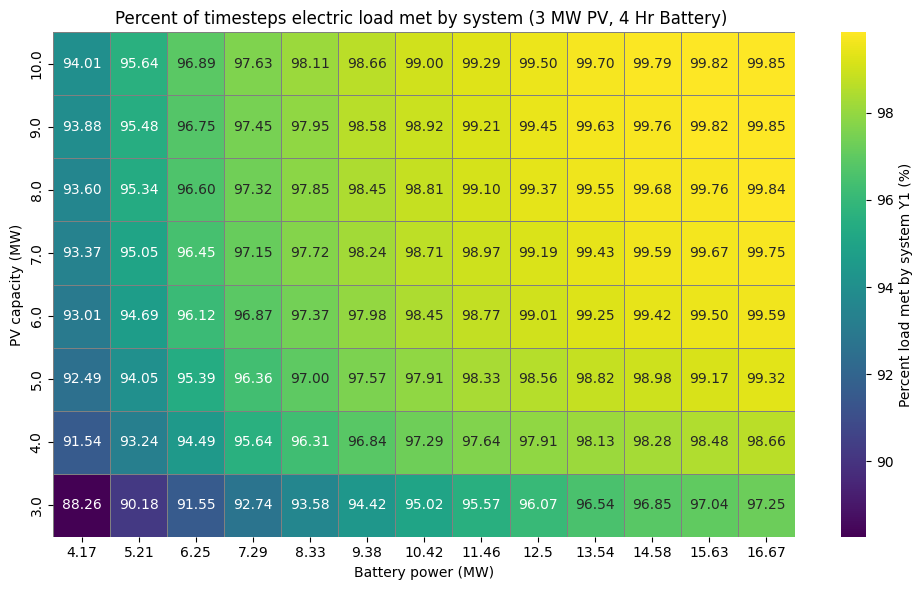

In [9]:
# Plot the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": f"{value_col} (%)"},
    linewidths=0.5,
    linecolor='gray'
)

# Axis labels including units
ax.set_xlabel(f"Battery power (MW)")
ax.set_ylabel(f"PV capacity (MW)")
ax.set_title("Percent of timesteps electric load met by system (3 MW PV, 4 Hr Battery) ")

# Ensure x ticks are the column values (hours) and are shown as integers if appropriate
ax.set_xticklabels([str(int(x)) if float(x).is_integer() else str(round(x, 2)) for x in pivot.columns], rotation=0)

# By default seaborn places the first row at the top. If you prefer smaller powers at the bottom, invert y axis:
ax.invert_yaxis()

plt.tight_layout()
#plt.show()

# Optionally save the figure
plt.savefig('hybrid_wind_heatmap.jpg', dpi=300)